# 📝 Problem Overview

This project focuses on classifying user comments into predefined categories using Natural Language Processing (NLP) techniques.

The objective is to build a robust machine learning pipeline that can effectively learn from textual data and predict labels for unseen comments.

---

# 🎯 Objectives

- Perform Exploratory Data Analysis (EDA) to understand the dataset  
- Convert text data into numerical representations using TF-IDF  
- Apply multiple machine learning models for classification  
- Evaluate and compare model performance  
- Improve performance using feature engineering and hyperparameter tuning  
- Generate predictions for the test dataset  

---

# ⚙️ Approach

The workflow includes:

1. Data Loading & Exploration  
2. Text Feature Engineering (TF-IDF)  
3. Feature Selection (Chi-Square)  
4. Model Training (Multiple Algorithms)  
5. Model Evaluation & Comparison  
6. Final Model Selection & Submission  

This structured approach ensures both performance and interpretability.

# 📦 Data Setup & Environment

In [1]:
# =========================================================
# 📚 IMPORT LIBRARIES
# =========================================================

# Core libraries
import os
import numpy as np
import pandas as pd

# Machine learning utilities
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score


# =========================================================
# 📂 DATASET LOCATION
# =========================================================

DATA_PATH = "/kaggle/input"


# =========================================================
# 🔍 EXPLORE AVAILABLE DATA FILES
# =========================================================

print("📁 Available Dataset Files:\n")

file_count = 0

for dirname, _, filenames in os.walk(DATA_PATH):
    for filename in filenames:
        print(f"📄 {filename}")
        file_count += 1

print(f"\n✅ Total files found: {file_count}")

📁 Available Dataset Files:

📄 Sample.csv
📄 train.csv
📄 test.csv

✅ Total files found: 3


# 📥 Data Loading & Initial Exploration

In [2]:
# =========================================================
# 📂 LOAD DATASETS
# =========================================================

BASE_PATH = "/kaggle/input/comment-category-prediction-challenge"

train_df  = pd.read_csv(f"{BASE_PATH}/train.csv")
test_df   = pd.read_csv(f"{BASE_PATH}/test.csv")
sample_df = pd.read_csv(f"{BASE_PATH}/Sample.csv")

print("✅ Data Loaded Successfully\n")


# =========================================================
# 📊 DATASET SHAPES
# =========================================================

print("📐 Dataset Shapes:\n")
print(f"Train Dataset  : {train_df.shape}")
print(f"Test Dataset   : {test_df.shape}")
print(f"Sample Dataset : {sample_df.shape}")


# =========================================================
# 🔍 SAMPLE DATA PREVIEW
# =========================================================

print("\n🔍 Sample Training Data:\n")
display(train_df.head())


# =========================================================
# 🧾 DATASET STRUCTURE
# =========================================================

print("\n🧾 Dataset Information:\n")
train_df.info()


# =========================================================
# ❗ MISSING VALUES
# =========================================================

print("\n❗ Missing Values:\n")
display(train_df.isnull().sum())

# =========================================================
# 📊 STATISTICAL SUMMARY
# =========================================================

print("\n📊 Numerical Feature Summary:\n")
display(train_df.describe())

✅ Data Loaded Successfully

📐 Dataset Shapes:

Train Dataset  : (198000, 15)
Test Dataset   : (102000, 14)
Sample Dataset : (102000, 2)

🔍 Sample Training Data:



,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2



🧾 Dataset Information:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB

❗ Missing Values:



created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64


📊 Numerical Feature Summary:



,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


# 🧹 Handling Missing Values

In [3]:
# =========================================================
# ❓ CHECK MISSING VALUES
# =========================================================

missing_values = train_df.isnull().sum()

print("❗ Missing Values Before Cleaning:\n")
display(missing_values[missing_values > 0])

print(f"\nTotal Missing Values: {missing_values.sum()}")


# =========================================================
# 🧹 HANDLE MISSING VALUES
# =========================================================

train_df["comment"] = train_df["comment"].fillna("")

train_df["race"] = train_df["race"].fillna("unknown")
train_df["religion"] = train_df["religion"].fillna("unknown")
train_df["gender"] = train_df["gender"].fillna("unknown")


# =========================================================
# ✅ VERIFY CLEANING
# =========================================================

missing_after = train_df.isnull().sum()
total_missing = missing_after.sum()

print("\n✅ Missing Values After Cleaning:\n")

# Check if there are 0 missing values
if total_missing == 0:
    print("Zero (0) missing values! The data is clean.")
else:
    # Only display columns that still have missing values
    display(missing_after[missing_after > 0])
    print(f"\nTotal Missing Values After Cleaning: {total_missing}")

❗ Missing Values Before Cleaning:



race        145423
religion    145423
gender      145423
comment          1
dtype: int64


Total Missing Values: 436270

✅ Missing Values After Cleaning:

Zero (0) missing values! The data is clean.


# ⚖️ Class Distribution Analysis

📊 Class Distribution:



,Count,Proportion
label,,
0,114173,0.576631
2,62440,0.315354
1,15918,0.080394
3,5469,0.027621


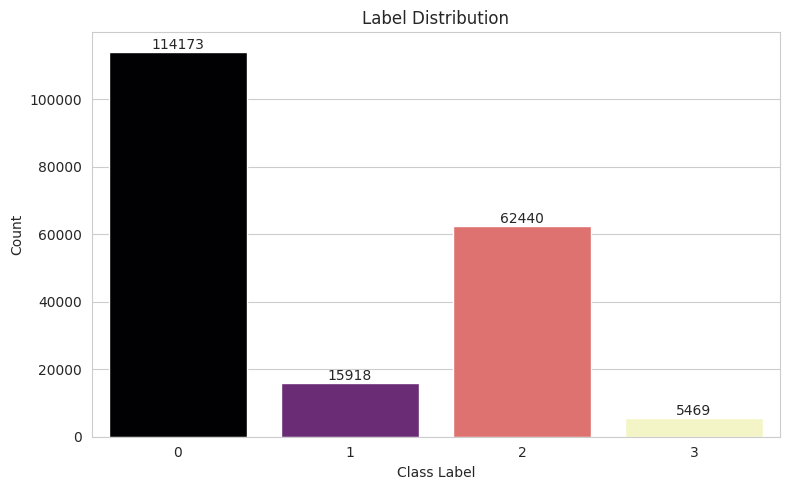

In [4]:
# =========================================================
# 📚 IMPORT VISUALIZATION LIBRARIES
# =========================================================

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

# =========================================================
# 📊 CLASS DISTRIBUTION (COUNTS + PROPORTIONS)
# =========================================================

label_counts = train_df["label"].value_counts()
label_dist = train_df["label"].value_counts(normalize=True)

class_df = pd.DataFrame({
    "Count": label_counts,
    "Proportion": label_dist
})

print("📊 Class Distribution:\n")
display(class_df)


# =========================================================
# 📈 CLASS DISTRIBUTION (VISUALIZATION)
# =========================================================

plt.figure(figsize=(8,5))

ax = sns.countplot(
    x="label",
    data=train_df,
    hue="label",
    palette="magma",
    legend=False
)

# Add count labels on bars
for p in ax.patches:
    ax.annotate(f"{int(p.get_height())}",
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom")

plt.title("Label Distribution")
plt.xlabel("Class Label")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

# 📝 Basic Text Analysis

📝 Comment Length Summary:



count    198000.000000
mean        302.909364
std         266.441749
min           0.000000
25%         102.000000
50%         211.000000
75%         419.000000
max        1892.000000
Name: comment_length, dtype: float64

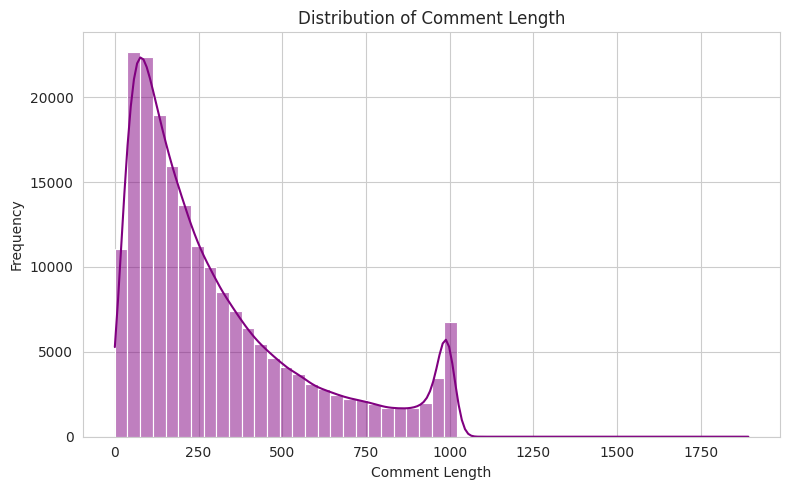

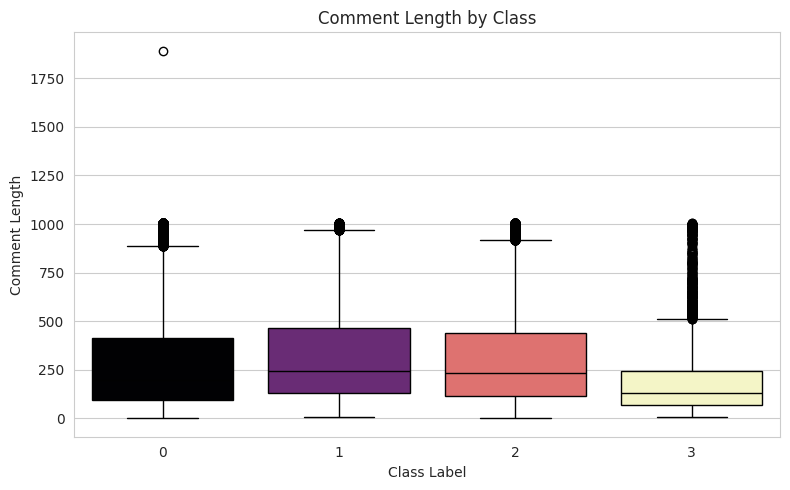

In [5]:
# =========================================================
# ✏️ FEATURE: COMMENT LENGTH
# =========================================================

train_df["comment_length"] = train_df["comment"].str.len()

print("📝 Comment Length Summary:\n")
display(train_df["comment_length"].describe())


# =========================================================
# 📊 COMMENT LENGTH DISTRIBUTION
# =========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data=train_df,
    x="comment_length",
    bins=50,
    kde=True,
    color="purple"
)

plt.title("Distribution of Comment Length")
plt.xlabel("Comment Length")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


# =========================================================
# 📦 COMMENT LENGTH BY CLASS 
# =========================================================

plt.figure(figsize=(8,5))

sns.boxplot(
    data=train_df,
    x="label",
    y="comment_length",
    hue="label",
    palette="magma",
    legend=False
)

plt.title("Comment Length by Class")
plt.xlabel("Class Label")
plt.ylabel("Comment Length")

plt.tight_layout()
plt.show()

# 🎯 Train–Validation Split

In [6]:
# =========================================================
# 🎯 FEATURE / TARGET SEPARATION
# =========================================================

X = train_df["comment"]
y = train_df["label"]


# =========================================================
# 🔀 STRATIFIED TRAIN–VALIDATION SPLIT
# =========================================================

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# =========================================================
# 📊 SPLIT SUMMARY
# =========================================================

print("✅ Split Completed\n")

print(f"📦 Training Samples   : {X_train.shape[0]}")
print(f"📦 Validation Samples : {X_val.shape[0]}")


# =========================================================
# ⚖️ CLASS DISTRIBUTION CHECK
# =========================================================

train_dist = y_train.value_counts(normalize=True)
val_dist   = y_val.value_counts(normalize=True)

dist_df = pd.DataFrame({
    "Train": train_dist,
    "Validation": val_dist
})

print("\n⚖️ Class Distribution After Split:\n")
display(dist_df)

✅ Split Completed

📦 Training Samples   : 158400
📦 Validation Samples : 39600

⚖️ Class Distribution After Split:



,Train,Validation
label,,
0,0.576629,0.576641
2,0.315354,0.315354
1,0.080398,0.080379
3,0.027620,0.027626


# 🔤 Text Vectorization (TF-IDF)

In [7]:
# =========================================================
# 🔤 TF-IDF VECTORIZATION
# =========================================================

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20_000,
    min_df=2,
    ngram_range=(1, 2)
)


# =========================================================
# ⚙️ FIT + TRANSFORM
# =========================================================

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)


# =========================================================
# 📊 FEATURE MATRIX SUMMARY
# =========================================================

print("✅ Vectorization Complete\n")

print(f"📦 Training Matrix Shape   : {X_train_tfidf.shape}")
print(f"📦 Validation Matrix Shape : {X_val_tfidf.shape}")

print(f"\n🔢 Total Features (Vocabulary Size): {len(tfidf.get_feature_names_out())}")


# =========================================================
# 🔍 SAMPLE FEATURES
# =========================================================

print("\n🔍 Sample Features:\n")
print(tfidf.get_feature_names_out()[:20])

✅ Vectorization Complete

📦 Training Matrix Shape   : (158400, 20000)
📦 Validation Matrix Shape : (39600, 20000)

🔢 Total Features (Vocabulary Size): 20000

🔍 Sample Features:

['00' '000' '000 00' '000 000' '000 dollars' '000 jobs' '000 people'
 '000 year' '000 years' '01' '02' '03' '04' '05' '06' '07' '08' '09' '10'
 '10 000']


# 🧩 Feature Engineering: Text + Numerical Fusion
Preparing a combined feature space by merging TF-IDF text features with scaled numerical attributes.

In [8]:
# =========================================================
# 🧩 FEATURE ENGINEERING
# =========================================================

from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack


# =========================================================
# 🔢 NUMERICAL FEATURE COLUMNS
# =========================================================

num_cols = [
    "emoticon_1", "emoticon_2", "emoticon_3",
    "upvote", "downvote",
    "if_1", "if_2", "disability"
]


# =========================================================
# 📥 EXTRACT NUMERICAL FEATURES
# =========================================================

X_train_num = train_df.loc[X_train.index, num_cols]
X_val_num   = train_df.loc[X_val.index, num_cols]


# =========================================================
# ⚙️ SCALE NUMERICAL FEATURES
# =========================================================

scaler = StandardScaler()

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled   = scaler.transform(X_val_num)


# =========================================================
# 🔗 COMBINE TEXT + NUMERICAL FEATURES
# =========================================================

X_train_combined = hstack([X_train_tfidf, X_train_num_scaled])
X_val_combined   = hstack([X_val_tfidf,   X_val_num_scaled])


# =========================================================
# 📊 FEATURE MATRIX SUMMARY
# =========================================================

print("📦 Text Feature Shape       :", X_train_tfidf.shape)
print("🔢 Numerical Feature Shape  :", X_train_num_scaled.shape)

print("\n🔗 Combined Feature Shape:")
print(f"Training   : {X_train_combined.shape}")
print(f"Validation : {X_val_combined.shape}")

# Contribution breakdown
text_features = X_train_tfidf.shape[1]
num_features  = X_train_num_scaled.shape[1]

print("\n📊 Feature Contribution:")
print(f"Text Features       : {text_features}")
print(f"Numerical Features  : {num_features}")
print(f"Total Features      : {text_features + num_features}")

📦 Text Feature Shape       : (158400, 20000)
🔢 Numerical Feature Shape  : (158400, 8)

🔗 Combined Feature Shape:
Training   : (158400, 20008)
Validation : (39600, 20008)

📊 Feature Contribution:
Text Features       : 20000
Numerical Features  : 8
Total Features      : 20008


# 🎯 Feature Selection — SelectKBest (Chi-Square)

SelectKBest identifies the most informative features using statistical tests.  
The chi-square test measures dependence between features and target labels, allowing removal of less useful features.

In [9]:
# =========================================================
# 🎯 FEATURE SELECTION — SelectKBest (Chi-Square)
# =========================================================

from sklearn.feature_selection import SelectKBest, chi2

selector = SelectKBest(
    score_func=chi2,
    k=5000
)


# =========================================================
# ⚙️ FIT + TRANSFORM
# =========================================================

X_train_sel = selector.fit_transform(X_train_tfidf, y_train)
X_val_sel   = selector.transform(X_val_tfidf)


# =========================================================
# 📊 FEATURE DIMENSION SUMMARY
# =========================================================

print("📦 Original TF-IDF Shape :", X_train_tfidf.shape)
print("📉 Reduced Feature Shape :", X_train_sel.shape)

reduction = 100 * (1 - (X_train_sel.shape[1] / X_train_tfidf.shape[1]))
print(f"\n📉 Feature Reduction: {reduction:.2f}%")


# =========================================================
# 🔍 TOP SELECTED FEATURES
# =========================================================

feature_names = tfidf.get_feature_names_out()
selected_mask = selector.get_support()

selected_features = feature_names[selected_mask]

print("\n🔍 Sample Selected Features:\n")
print(selected_features[:20])

📦 Original TF-IDF Shape : (158400, 20000)
📉 Reduced Feature Shape : (158400, 5000)

📉 Feature Reduction: 75.00%

🔍 Sample Selected Features:

['00' '000' '000 year' '05' '10' '10 000' '10 times' '10 years' '100'
 '100k' '103' '11' '12' '13' '15' '16' '17' '1960s' '1965' '1980']


# 🧩 Categorical Feature Encoding

Categorical features such as race, religion, and gender are encoded using OneHotEncoder.

This allows the model to utilize structured demographic information alongside text features.

In [10]:
# =========================================================
# 🧩 CATEGORICAL FEATURE ENCODING
# =========================================================

from sklearn.preprocessing import OneHotEncoder

cat_cols = ["race", "religion", "gender"]

ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)

X_train_cat = ohe.fit_transform(train_df.loc[X_train.index, cat_cols])
X_val_cat   = ohe.transform(train_df.loc[X_val.index, cat_cols])

# =========================================================
# 📊 CATEGORICAL FEATURE SUMMARY
# =========================================================

print("📦 Categorical Feature Shape:", X_train_cat.shape)

print(f"\n🔢 Total Encoded Features: {X_train_cat.shape[1]}")


# =========================================================
# 🔍 ENCODED FEATURE NAMES
# =========================================================

feature_names = ohe.get_feature_names_out(cat_cols)

print("\n🔍 Sample Encoded Features:\n")
print(feature_names[:20])

📦 Categorical Feature Shape: (158400, 22)

🔢 Total Encoded Features: 22

🔍 Sample Encoded Features:

['race_asian' 'race_black' 'race_latino' 'race_none' 'race_other'
 'race_unknown' 'race_white' 'religion_atheist' 'religion_buddhist'
 'religion_christian' 'religion_hindu' 'religion_jewish' 'religion_muslim'
 'religion_none' 'religion_other' 'religion_unknown' 'gender_female'
 'gender_male' 'gender_none' 'gender_other']


# 🔽 Dimensionality Reduction: Truncated SVD

Reducing high-dimensional sparse TF-IDF features into a compact dense latent space to capture key semantic structure while lowering computational cost.

In [11]:
# =========================================================
# 🔽 DIMENSIONALITY REDUCTION: TRUNCATED SVD
# =========================================================

from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(
    n_components=300,
    random_state=42
)


# =========================================================
# ⚙️ FIT + TRANSFORM
# =========================================================

X_train_svd = svd.fit_transform(X_train_combined)
X_val_svd   = svd.transform(X_val_combined)


# =========================================================
# 📊 DIMENSION SUMMARY
# =========================================================

print("📦 Original Feature Shape :", X_train_combined.shape)
print("📉 Reduced Feature Shape :", X_train_svd.shape)

reduction = 100 * (1 - (X_train_svd.shape[1] / X_train_combined.shape[1]))
print(f"\n📉 Dimensionality Reduction: {reduction:.2f}%")


# =========================================================
# 🔍 EXPLAINED VARIANCE
# =========================================================

explained_var = svd.explained_variance_ratio_.sum()

print(f"\n📊 Total Explained Variance: {explained_var:.4f}")

📦 Original Feature Shape : (158400, 20008)
📉 Reduced Feature Shape : (158400, 300)

📉 Dimensionality Reduction: 98.50%

📊 Total Explained Variance: 0.9101


# 🤖 Model 1: Logistic Regression (Baseline)

Training a baseline Logistic Regression classifier using TF-IDF features and evaluating performance on the validation set.

📊 Logistic Regression Performance

✅ Validation Accuracy: 0.7861

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.91      0.84     22835
           1       0.74      0.56      0.64      3183
           2       0.80      0.66      0.72     12488
           3       0.67      0.30      0.41      1094

    accuracy                           0.79     39600
   macro avg       0.75      0.61      0.65     39600
weighted avg       0.78      0.79      0.78     39600



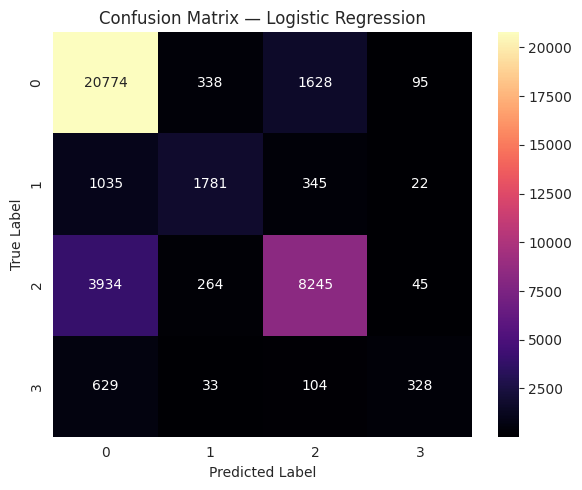

⚠️ Note: Model struggles with minority classes due to imbalance.


In [12]:
# =========================================================
# 🤖 MODEL 1: LOGISTIC REGRESSION
# =========================================================

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    max_iter=1000
)

lr_model.fit(X_train_tfidf, y_train)


# =========================================================
# 🔮 VALIDATION PREDICTIONS
# =========================================================

val_preds = lr_model.predict(X_val_tfidf)


# =========================================================
# 📊 MODEL EVALUATION
# =========================================================

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_val, val_preds)


# =========================================================
# 📊 MODEL PERFORMANCE SUMMARY
# =========================================================

print("📊 Logistic Regression Performance\n")

print(f"✅ Validation Accuracy: {accuracy:.4f}\n")

print("📋 Classification Report:\n")
print(classification_report(y_val, val_preds))


# =========================================================
# 📉 CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(y_val, val_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()


print("⚠️ Note: Model struggles with minority classes due to imbalance.")

# 🤖 Model 2: Multinomial Naive Bayes

Training a Multinomial Naive Bayes classifier on TF-IDF features and evaluating performance on the validation set.

📊 Multinomial Naive Bayes Performance

Validation Accuracy: 0.7173

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.71      0.91      0.80     22835
           1       0.72      0.39      0.51      3183
           2       0.74      0.50      0.60     12488
           3       0.80      0.03      0.05      1094

    accuracy                           0.72     39600
   macro avg       0.74      0.46      0.49     39600
weighted avg       0.72      0.72      0.69     39600



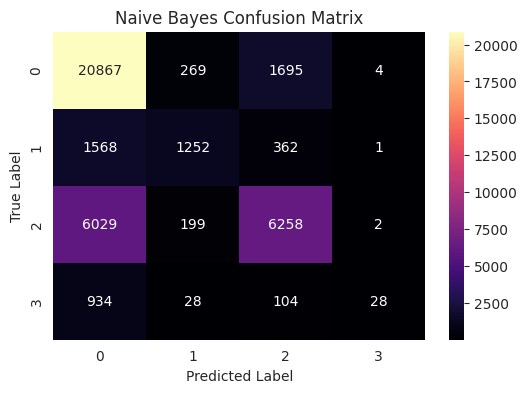

In [13]:
# =========================================================
# 🤖 MODEL 2: MULTINOMIAL NAIVE BAYES
# =========================================================

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================================================
# ⚙️ TRAIN MODEL
# =========================================================

nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)


# =========================================================
# 🔮 VALIDATION PREDICTIONS
# =========================================================

nb_preds = nb_model.predict(X_val_tfidf)


# =========================================================
# 📊 MODEL EVALUATION
# =========================================================

nb_accuracy = accuracy_score(y_val, nb_preds)

print("📊 Multinomial Naive Bayes Performance\n")
print(f"Validation Accuracy: {nb_accuracy:.4f}\n")

print("📋 Classification Report:\n")
print(classification_report(y_val, nb_preds))


# =========================================================
# 📉 CONFUSION MATRIX
# =========================================================

nb_cm = confusion_matrix(y_val, nb_preds)

plt.figure(figsize=(6,4))

sns.heatmap(
    nb_cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# 🤖 Model 3: Support Vector Machine (SVM)

Support Vector Machines construct optimal hyperplanes to separate classes in high-dimensional space.  
They are effective for sparse text features and maximize margin between classes.

📊 Support Vector Machine Performance

✅ Validation Accuracy: 0.7924

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.90      0.85     22835
           1       0.72      0.60      0.65      3183
           2       0.79      0.69      0.74     12488
           3       0.63      0.34      0.44      1094

    accuracy                           0.79     39600
   macro avg       0.74      0.63      0.67     39600
weighted avg       0.79      0.79      0.79     39600



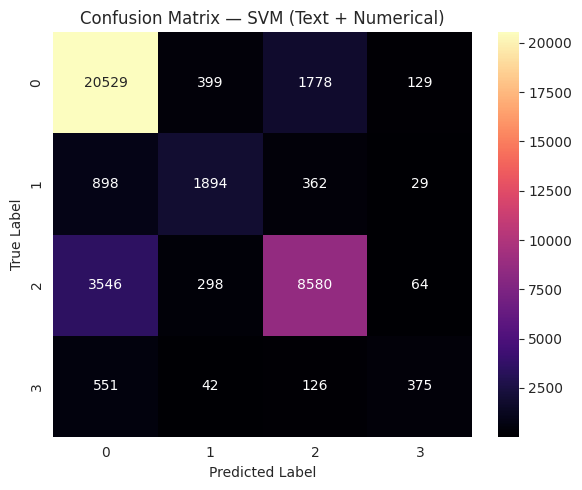

In [14]:
# =========================================================
# 🤖 MODEL 3: SUPPORT VECTOR MACHINE
# =========================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================================================
# ⚙️ TRAIN MODEL
# =========================================================

svm_model = LinearSVC(C=1.0)

svm_model.fit(X_train_combined, y_train)


# =========================================================
# 🔮 VALIDATION PREDICTIONS
# =========================================================

svm_preds = svm_model.predict(X_val_combined)


# =========================================================
# 📊 MODEL EVALUATION
# =========================================================

svm_accuracy = accuracy_score(y_val, svm_preds)


print("📊 Support Vector Machine Performance\n")

print(f"✅ Validation Accuracy: {svm_accuracy:.4f}\n")

print("📋 Classification Report:\n")
print(classification_report(y_val, svm_preds))


# =========================================================
# 📉 CONFUSION MATRIX
# =========================================================

svm_cm = confusion_matrix(y_val, svm_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    svm_cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.title("Confusion Matrix — SVM (Text + Numerical)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# 🤖 Model 4: Logistic Regression (Feature Engineering)
Combining linguistic and behavioral signals for improved classification performance.

📊 Logistic Regression (Feature Engineering)

✅ Validation Accuracy: 0.9009

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.95      0.95     22835
           1       0.79      0.71      0.75      3183
           2       0.85      0.90      0.88     12488
           3       0.73      0.47      0.57      1094

    accuracy                           0.90     39600
   macro avg       0.83      0.76      0.79     39600
weighted avg       0.90      0.90      0.90     39600



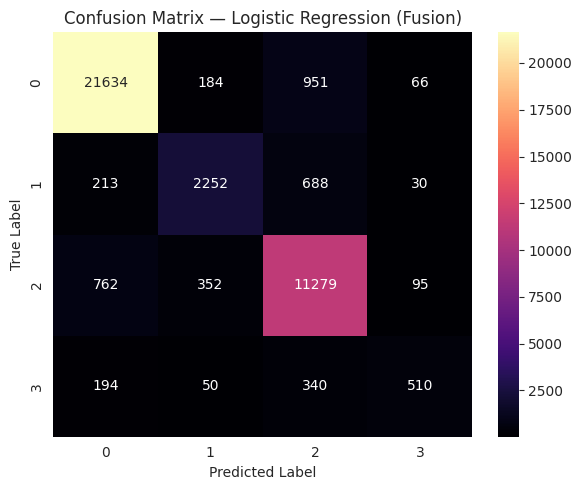

In [15]:
# =========================================================
# 🤖 MODEL 4: Logistic Regression (Feature Engineering)
# =========================================================

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================================================
# ⚙️ TRAIN MODEL
# =========================================================

fusion_lr = LogisticRegression(
    C=2,
    max_iter=2000
)

fusion_lr.fit(X_train_combined, y_train)


# =========================================================
# 🔮 VALIDATION PREDICTIONS
# =========================================================

fusion_preds = fusion_lr.predict(X_val_combined)


# =========================================================
# 📊 MODEL EVALUATION
# =========================================================

fusion_accuracy = accuracy_score(y_val, fusion_preds)

print("📊 Logistic Regression (Feature Engineering)\n")

print(f"✅ Validation Accuracy: {fusion_accuracy:.4f}\n")

print("📋 Classification Report:\n")
print(classification_report(y_val, fusion_preds))


# =========================================================
# 📉 CONFUSION MATRIX
# =========================================================

fusion_cm = confusion_matrix(y_val, fusion_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    fusion_cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.title("Confusion Matrix — Logistic Regression (Fusion)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# 🏆 Model 5: Feature Selection + Numerical Feature Fusion (Best Performing)

This model combines statistically selected TF-IDF text features with structured numerical metadata.

Feature Selection removes noisy and irrelevant words using the chi-square test, improving generalization and reducing dimensionality.

This configuration achieved the best validation performance among all models.

📊 Best Model Performance (Selected TF-IDF + Numerical)

🏆 Validation Accuracy: 0.9064

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.74      0.78      0.76      3183
           2       0.85      0.92      0.88     12488
           3       0.59      0.66      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.79      0.82      0.81     39600
weighted avg       0.91      0.91      0.91     39600

⚠️ Note: Improved recall for minority classes using class weights + feature selection



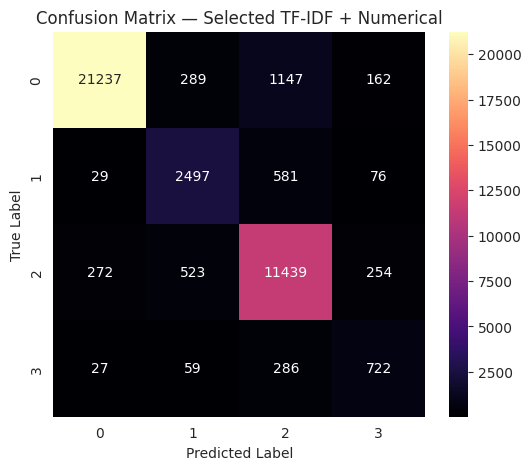

In [16]:
# =========================================================
# 🏆 MODEL 5: Feature Selection + Numerical Feature Fusion
# =========================================================

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================================================
# 🔗 COMBINE SELECTED TEXT + NUMERICAL FEATURES
# =========================================================

X_train_sel_combined = np.hstack([
    X_train_sel.toarray(),
    X_train_num_scaled
])

X_val_sel_combined = np.hstack([
    X_val_sel.toarray(),
    X_val_num_scaled
])


# =========================================================
# ⚙️ TRAIN MODEL
# =========================================================

best_lr = LogisticRegression(
    C=2,
    max_iter=2000,
    class_weight={0:1, 1:3, 2:2, 3:5}
)

best_lr.fit(X_train_sel_combined, y_train)


# =========================================================
# 🔮 VALIDATION PREDICTIONS
# =========================================================

best_preds = best_lr.predict(X_val_sel_combined)


# =========================================================
# 📊 MODEL EVALUATION
# =========================================================

best_accuracy = accuracy_score(y_val, best_preds)

print("📊 Best Model Performance (Selected TF-IDF + Numerical)\n")

print(f"🏆 Validation Accuracy: {best_accuracy:.4f}\n")

print("📋 Classification Report:\n")
print(classification_report(y_val, best_preds))

print("⚠️ Note: Improved recall for minority classes using class weights + feature selection\n")


# =========================================================
# 📉 CONFUSION MATRIX
# =========================================================

best_cm = confusion_matrix(y_val, best_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    best_cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.title("Confusion Matrix — Selected TF-IDF + Numerical")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# 🤝 Model 6: Voting Classifier (Ensemble Learning)

Voting Classifier combines predictions from multiple models.  
Each model votes for a class, and the final prediction is determined by majority voting.

This ensemble integrates Logistic Regression, Support Vector Machine, and Naive Bayes to leverage the strengths of different learning algorithms.

📊 Voting Classifier (Ensemble Model)

🤝 Validation Accuracy: 0.7840

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.91      0.84     22835
           1       0.74      0.55      0.63      3183
           2       0.80      0.66      0.72     12488
           3       0.69      0.28      0.40      1094

    accuracy                           0.78     39600
   macro avg       0.75      0.60      0.65     39600
weighted avg       0.78      0.78      0.77     39600

⚠️ Note: Combines predictions from multiple models using majority voting



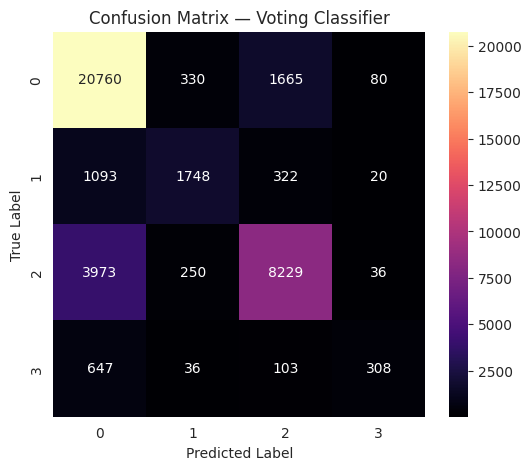

In [17]:
# =========================================================
# 🤝 MODEL 6: VOTING CLASSIFIER (ENSEMBLE)
# =========================================================

from sklearn.ensemble import VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import seaborn as sns
import matplotlib.pyplot as plt


# =========================================================
# ⚙️ INITIALIZE ENSEMBLE MODEL
# =========================================================

voting_model = VotingClassifier(
    estimators=[
        ("lr", lr_model),     # Logistic Regression
        ("svm", svm_model),   # Support Vector Machine
        ("nb", nb_model)      # Naive Bayes
    ],
    voting="hard",
    n_jobs=-1
)


# =========================================================
# 🚀 TRAIN MODEL
# =========================================================

voting_model.fit(X_train_tfidf, y_train)


# =========================================================
# 🔮 VALIDATION PREDICTIONS
# =========================================================

voting_preds = voting_model.predict(X_val_tfidf)


# =========================================================
# 📊 MODEL EVALUATION
# =========================================================

voting_accuracy = accuracy_score(y_val, voting_preds)

print("📊 Voting Classifier (Ensemble Model)\n")

print(f"🤝 Validation Accuracy: {voting_accuracy:.4f}\n")

print("📋 Classification Report:\n")
print(classification_report(y_val, voting_preds))

print("⚠️ Note: Combines predictions from multiple models using majority voting\n")
# =========================================================
# 📉 CONFUSION MATRIX
# =========================================================

voting_cm = confusion_matrix(y_val, voting_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    voting_cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.title("Confusion Matrix — Voting Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

# 🤖 Model 7: Hyperparameter Tuning (Logistic Regression)

To improve model performance, we perform hyperparameter tuning on Logistic Regression.

We focus on the regularization parameter **C**, which controls the trade-off between bias and variance.

GridSearchCV is used with cross-validation to identify the optimal parameter setting while ensuring reliable evaluation.

Fitting 3 folds for each of 4 candidates, totalling 12 fits
📊 Hyperparameter Tuned Logistic Regression
Best Parameters Found: {'C': 5}
✅ Validation Accuracy: 0.7942

📋 Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.91      0.85     22835
           1       0.74      0.60      0.66      3183
           2       0.80      0.68      0.74     12488
           3       0.66      0.32      0.43      1094

    accuracy                           0.79     39600
   macro avg       0.75      0.63      0.67     39600
weighted avg       0.79      0.79      0.79     39600

⚠️ Note: Parameters selected using 3-fold cross-validation



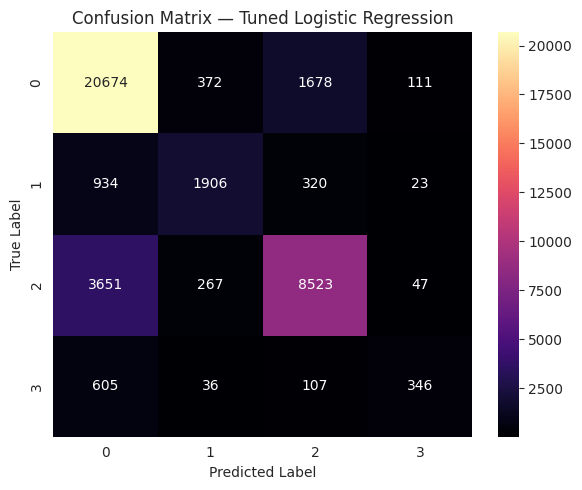

In [18]:
# =========================================================
# 🤖 MODEL 7: HYPERPARAMETER TUNING (LOGISTIC REGRESSION)
# =========================================================

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


# =========================================================
# 🔍 PARAMETER GRID
# =========================================================

param_grid = {
    "C": [0.5, 1, 2, 5]
}


# =========================================================
# ⚙️ GRID SEARCH SETUP
# =========================================================

grid = GridSearchCV(
    estimator=LogisticRegression(
        max_iter=1000,
        solver="liblinear"
    ),
    param_grid=param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=1,
    verbose=1
)


# =========================================================
# 🚀 MODEL TRAINING
# =========================================================

grid.fit(X_train_sel, y_train)

tuned_lr = grid.best_estimator_

print("📊 Hyperparameter Tuned Logistic Regression")

print("Best Parameters Found:", grid.best_params_)


# =========================================================
# 🔮 VALIDATION PREDICTIONS
# =========================================================

tuned_preds = tuned_lr.predict(X_val_sel)


# =========================================================
# 📊 MODEL EVALUATION
# =========================================================

tuned_acc = accuracy_score(y_val, tuned_preds)

print(f"✅ Validation Accuracy: {tuned_acc:.4f}\n")

print("📋 Classification Report:\n")
print(classification_report(y_val, tuned_preds))

print("⚠️ Note: Parameters selected using 3-fold cross-validation\n")


# =========================================================
# 📉 CONFUSION MATRIX
# =========================================================

tuned_cm = confusion_matrix(y_val, tuned_preds)

plt.figure(figsize=(6,5))

sns.heatmap(
    tuned_cm,
    annot=True,
    fmt="d",
    cmap="magma"
)

plt.title("Confusion Matrix — Tuned Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()
plt.show()

# 📊 Model Comparison Summary

Comparison of all trained models based on validation accuracy.

,Model,Accuracy,Rank
0,LR (Feature Selection + Numerical),0.906439,1
1,LR (Feature Engineering),0.900884,2
2,LR (Tuned),0.794167,3
3,LinearSVC (Text + Num),0.792374,4
4,LR (Text),0.786061,5
5,Voting Ensemble,0.783965,6
6,NB (Text),0.717298,7


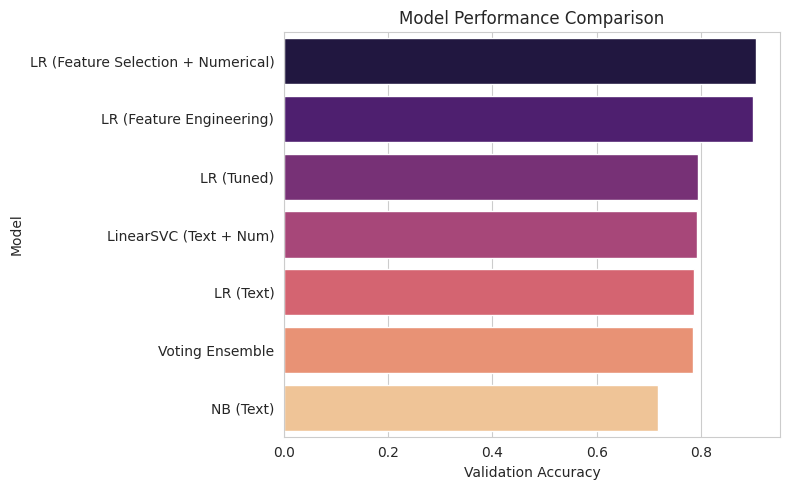

🏆 Best Model: LR (Feature Selection + Numerical)
📈 Accuracy : 0.9064


In [19]:
# =========================================================
# 📊 CREATE RESULTS TABLE
# =========================================================

results_df = pd.DataFrame({
    "Model": [
        "LR (Text)",
        "NB (Text)",
        "LinearSVC (Text + Num)",
        "LR (Feature Engineering)",
        "LR (Feature Selection + Numerical)",
        "Voting Ensemble",
        "LR (Tuned)"
    ],
    "Accuracy": [
        accuracy,
        nb_accuracy,
        svm_accuracy,
        fusion_accuracy,
        best_accuracy,
        voting_accuracy,
        tuned_acc
    ]
})

# Sort + Rank
results_df = results_df.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
results_df["Rank"] = results_df.index + 1

display(results_df)


# =========================================================
# 📈 VISUALIZE MODEL PERFORMANCE
# =========================================================

plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x="Accuracy",
    y="Model",
    hue="Model",
    palette="magma",
    legend=False
)

plt.title("Model Performance Comparison")
plt.xlabel("Validation Accuracy")
plt.ylabel("Model")

plt.tight_layout()
plt.show()


# =========================================================
# 🏆 BEST MODEL SUMMARY
# =========================================================

best_model_name = results_df.iloc[0]["Model"]
best_score = results_df.iloc[0]["Accuracy"]

print(f"🏆 Best Model: {best_model_name}")
print(f"📈 Accuracy : {best_score:.4f}")

# 🧠 Key Insights

- TF-IDF provided a strong baseline by effectively capturing textual patterns.
- Feature engineering (combining text with numerical features) led to a significant performance improvement.
- Feature selection using chi-square reduced noise and improved generalization.
- Handling class imbalance using class weights substantially improved recall for minority classes.
- Hyperparameter tuning resulted in only marginal gains compared to feature engineering.
- Ensemble methods did not outperform the best model due to inconsistent feature usage and model constraints.

Overall, combining feature selection, feature fusion, and class imbalance handling produced the best performance.

# 🏁 Final Model Selection

This section selects which trained model will be used for generating the final Kaggle submission.

Switching between models only requires updating the assignments below without modifying the training pipelines.

In [20]:
# =========================================================
# 🏁 FINAL MODEL SELECTOR
# =========================================================

# Choose ONE model by uncommenting


# ---------------------------------------------------------
# Model 1 — Logistic Regression (Baseline)
# ---------------------------------------------------------
# final_model = lr_model
# final_tfidf = tfidf
# use_numerical = False
# use_selected = False


# ---------------------------------------------------------
# Model 2 — Naive Bayes
# ---------------------------------------------------------
# final_model = nb_model
# final_tfidf = tfidf
# use_numerical = False
# use_selected = False


# ---------------------------------------------------------
# Model 3 — Support Vector Machine
# ---------------------------------------------------------
# final_model = svm_model
# final_tfidf = tfidf
# use_numerical = True
# use_selected = False


# ---------------------------------------------------------
# Model 4 — Logistic Regression (Feature Engineering)
# ---------------------------------------------------------
# final_model = fusion_lr
# final_tfidf = tfidf
# use_numerical = True
# use_selected = False


# ---------------------------------------------------------
# ⭐ Model 5 — Feature Selection + Numerical Feature Fusion
# ---------------------------------------------------------
final_model = best_lr
final_tfidf = tfidf
use_numerical = True
use_selected = True


# ---------------------------------------------------------
# Model 6 — Voting Classifier (Ensemble Learning)
# ---------------------------------------------------------
# final_model = voting_model
# final_tfidf = tfidf
# use_numerical = False
# use_selected = False


# ---------------------------------------------------------
# Model 7 — Hyperparameter tuned LR
# ---------------------------------------------------------
# final_model = tuned_lr
# final_tfidf = tfidf
# use_numerical = False
# use_selected = True

# 🏁 Conclusion

This project demonstrated a complete machine learning pipeline for text classification using TF-IDF and multiple models.

Among all approaches, Logistic Regression with feature-selected text and numerical features provided the most reliable performance.

The workflow highlights the importance of proper feature engineering, model comparison, and evaluation in building effective NLP systems.

# 🧪 Dummy Submission (Kaggle Registration)

In [21]:
# # =========================================================
# # 📂 DATA PATH
# # =========================================================
# BASE_PATH = "/kaggle/input/comment-category-prediction-challenge"


# # =========================================================
# # 📥 LOAD DATA
# # =========================================================
# train_df = pd.read_csv(f"{BASE_PATH}/train.csv")
# test_df = pd.read_csv(f"{BASE_PATH}/test.csv")
# sample_df = pd.read_csv(f"{BASE_PATH}/Sample.csv")

# print("Train shape:", train_df.shape)
# print("Test shape:", test_df.shape)


# # =========================================================
# # 🎯 FEATURES & TARGET
# # =========================================================
# X = train_df["comment"]
# y = train_df["label"]


# # =========================================================
# # 🔀 TRAIN / VALIDATION SPLIT
# # =========================================================
# X_train, X_val, y_train, y_val = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42,
#     stratify=y
# )


# # =========================================================
# # 🤖 BASELINE MODEL (Dummy Classifier)
# # =========================================================
# model = DummyClassifier(strategy="most_frequent")
# model.fit(X_train.values.reshape(-1, 1), y_train)


# # =========================================================
# # 📊 VALIDATION PERFORMANCE
# # =========================================================
# val_preds = model.predict(X_val.values.reshape(-1, 1))
# val_acc = accuracy_score(y_val, val_preds)

# print(f"Validation Accuracy: {val_acc:.4f}")


# # =========================================================
# # 🔮 TEST PREDICTIONS
# # =========================================================
# test_preds = model.predict(test_df["comment"].values.reshape(-1, 1))


# # =========================================================
# # 📤 CREATE SUBMISSION FILE
# # =========================================================
# submission = pd.DataFrame({
#     "ID": sample_df["ID"],
#     "label": test_preds
# })

# submission.to_csv("submission.csv", index=False)

# print("✅ submission.csv created successfully")

# 📤 Submission

Generating predictions on the test dataset using the selected final model and preparing the Kaggle submission file.

In [22]:
# =========================================================
# 📤 UNIVERSAL SUBMISSION BLOCK
# =========================================================

import numpy as np


# =========================================================
# 🔤 TEXT FEATURES
# =========================================================

test_tfidf = final_tfidf.transform(test_df["comment"])

if use_selected:
    test_text_features = selector.transform(test_tfidf).toarray()
else:
    test_text_features = test_tfidf.toarray()


# =========================================================
# 🔢 NUMERICAL FEATURES
# =========================================================

if use_numerical:

    num_cols = [
        "emoticon_1", "emoticon_2", "emoticon_3",
        "upvote", "downvote",
        "if_1", "if_2", "disability"
    ]

    X_test_num = test_df[num_cols]
    X_test_num_scaled = scaler.transform(X_test_num)

    test_features = np.hstack([
        test_text_features,
        X_test_num_scaled
    ])

else:
    test_features = test_text_features


# =========================================================
# 🔮 PREDICTIONS
# =========================================================

test_preds = final_model.predict(test_features)


# =========================================================
# 📄 CREATE SUBMISSION FILE
# =========================================================

submission = pd.DataFrame({
    "ID": sample_df["ID"],
    "label": test_preds
})

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully")

submission.csv created successfully
